In [1]:
from IPython.display import HTML, display
display(HTML("""
<style>
table { margin-left: 0 !important; margin-right: auto !important; }
.jp-RenderedHTMLCommon table { margin-left: 0 !important; margin-right: auto !important; }
.jp-RenderedMarkdown table { margin-left: 0 !important; margin-right: auto !important; }
</style>
"""))

<style>
table { margin-left: 0 !important; margin-right: auto !important; }
.jp-RenderedHTMLCommon table { margin-left: 0 !important; margin-right: auto !important; }
.jp-RenderedMarkdown table { margin-left: 0 !important; margin-right: auto !important; }
</style>
# **YOLOv10 Architecture Summary**

---

## YAML Format Structure

Each layer is defined as: `[from, repeats, module, args]`

| Parameter | Description |
|-----------|-------------|
| **from** | Input source (`-1` = previous layer, or layer index, or list for multiple inputs) |
| **repeats** | How many times to repeat this module |
| **module** | The class/module type to instantiate |
| **args** | Arguments passed to the module constructor |

## Module Classes and Locations

> All modules are located in the `ultralytics/nn/modules/` directory.

| Module | File | Description |
|:-------|:-----|:------------|
| `Conv` | `conv.py:37` | Standard Conv + BatchNorm + SiLU |
| `C2f` | `block.py:277` | CSP Bottleneck with 2 convolutions (faster) |
| `SPPF` | `block.py:199` | Spatial Pyramid Pooling - Fast |
| `PSA` | `block.py:1383` | Position-Sensitive Attention |
| `SCDown` | `block.py:1539` | Spatial-Channel Decoupled Downsampling |
| `C2fCIB` | `block.py:1236` | C2f with Compact Inverted Block |
| `Concat` | `conv.py:655` | Tensor concatenation |
| `v10Detect` | `head.py:841` | YOLOv10 detection head |

## Backbone (Layers 0-10)

| Layer | YAML | Class | Args | Description |
|:-----:|:-----|:------|:-----|:------------|
| 0 | `[-1, 1, Conv, [64, 3, 2]]` | Conv | `c2=64, k=3, s=2` | Stem layer, P1/2 downsample |
| 1 | `[-1, 1, Conv, [128, 3, 2]]` | Conv | `c2=128, k=3, s=2` | P2/4 downsample |
| 2 | `[-1, 3, C2f, [128, True]]` | C2f | `c2=128, shortcut=True` | 3x Bottleneck with shortcuts |
| 3 | `[-1, 1, Conv, [256, 3, 2]]` | Conv | `c2=256, k=3, s=2` | P3/8 downsample |
| 4 | `[-1, 6, C2f, [256, True]]` | C2f | `c2=256, shortcut=True` | 6x Bottleneck with shortcuts |
| 5 | `[-1, 1, SCDown, [512, 3, 2]]` | SCDown | `c2=512, k=3, s=2` | Efficient downsample, P4/16 |
| 6 | `[-1, 6, C2f, [512, True]]` | C2f | `c2=512, shortcut=True` | Feature extraction at P4 |
| 7 | `[-1, 1, SCDown, [1024, 3, 2]]` | SCDown | `c2=1024, k=3, s=2` | Efficient downsample, P5/32 |
| 8 | `[-1, 3, C2f, [1024, True]]` | C2f | `c2=1024, shortcut=True` | Deep feature extraction |
| 9 | `[-1, 1, SPPF, [1024, 5]]` | SPPF | `c2=1024, k=5` | Multi-scale context |
| 10 | `[-1, 1, PSA, [1024]]` | PSA | `c=1024` | **Attention module** |

## Head / Neck (Layers 11-23)

| Layer | YAML | Class | Args | Description |
|:-----:|:-----|:------|:-----|:------------|
| 11 | `[-1, 1, nn.Upsample, [None, 2, "nearest"]]` | Upsample | `scale=2` | 2x upsampling |
| 12 | `[[-1, 6], 1, Concat, [1]]` | Concat | `dim=1` | Merge with backbone P4 (FPN) |
| 13 | `[-1, 3, C2f, [512]]` | C2f | `c2=512` | Feature fusion |
| 14 | `[-1, 1, nn.Upsample, [None, 2, "nearest"]]` | Upsample | `scale=2` | 2x upsampling |
| 15 | `[[-1, 4], 1, Concat, [1]]` | Concat | `dim=1` | Merge with backbone P3 |
| 16 | `[-1, 3, C2f, [256]]` | C2f | `c2=256` | **P3/8 output** (small objects) |
| 17 | `[-1, 1, Conv, [256, 3, 2]]` | Conv | `c2=256, k=3, s=2` | PANet downsample |
| 18 | `[[-1, 13], 1, Concat, [1]]` | Concat | `dim=1` | Merge with head P4 |
| 19 | `[-1, 3, C2f, [512]]` | C2f | `c2=512` | **P4/16 output** (medium objects) |
| 20 | `[-1, 1, SCDown, [512, 3, 2]]` | SCDown | `c2=512, k=3, s=2` | Efficient downsample |
| 21 | `[[-1, 10], 1, Concat, [1]]` | Concat | `dim=1` | Merge with PSA output |
| 22 | `[-1, 3, C2fCIB, [1024, True, True]]` | C2fCIB | `c2=1024, lk=True` | **P5/32 output** (large objects) |
| 23 | `[[16, 19, 22], 1, v10Detect, [nc]]` | v10Detect | `nc=80` | Detection head (NMS-free) |

---

## Detailed Class Architectures

### Conv (Standard Convolution Block)

```
Input -> Conv2d -> BatchNorm2d -> SiLU -> Output
```

| Argument | Description | Default |
|:---------|:------------|:--------|
| `c1` | Input channels | - |
| `c2` | Output channels | - |
| `k` | Kernel size | 1 |
| `s` | Stride | 1 |
| `p` | Padding | auto |
| `g` | Groups | 1 |
| `act` | Activation | SiLU |

### C2f (CSP Bottleneck with 2 Convolutions - Faster)

```
Input → Conv1×1 → Split
                   ├── Chunk A: pass through
                   └── Chunk B: Bottleneck×n
              → Concat all → Conv1×1 → Output
```

| Argument | Description | Default |
|:---------|:------------|:--------|
| `c1` | Input channels | - |
| `c2` | Output channels | - |
| `n` | Number of Bottleneck blocks | - |
| `shortcut` | Use residual connections | True |
| `g` | Groups | 1 |
| `e` | Expansion ratio | 0.5 |

### SPPF (Spatial Pyramid Pooling - Fast)

```
Input → Conv1×1 → MaxPool5×5 → MaxPool5×5 → MaxPool5×5
                → Concat(original + 3 pooled) → Conv1×1 → Output
```

> **Purpose:** Captures multi-scale spatial context. Equivalent to SPP(k=5,9,13) but faster.

| Argument | Description | Default |
|:---------|:------------|:--------|
| `c1` | Input channels | - |
| `c2` | Output channels | - |
| `k` | MaxPool kernel size | 5 |

### PSA (Position-Sensitive Attention)

```
Input -> Conv1x1 -> Split(a, b)
                   |-- a: pass through
                   +-- b: Attention(QKV + PE) -> FFN
              -> Concat(a, b) -> Conv1x1 -> Output
```

> **Attention Details:**
> - Multi-head self-attention with learnable positional encoding
> - `num_heads = c // 64`
> - `attn_ratio = 0.5`

| Argument | Description | Default |
|:---------|:------------|:--------|
| `c1` | Input channels | - |
| `c2` | Output channels (must equal c1) | - |
| `e` | Expansion ratio | 0.5 |

### SCDown (Spatial-Channel Decoupled Downsampling)

```
Input → Conv1×1 (channel mixing) → DepthwiseConv (spatial downsample) → Output
```

> **Purpose:** More efficient than standard strided convolution by separating channel transformation and spatial downsampling.

| Argument | Description |
|:---------|:------------|
| `c1` | Input channels |
| `c2` | Output channels |
| `k` | Kernel size |
| `s` | Stride |

### C2fCIB (C2f with Compact Inverted Block)

```
Same as C2f, but Bottleneck replaced with CIB:

CIB: Input → DWConv3×3 → Conv1×1 → Conv1×1 → DWConv3×3 → +shortcut → Output
```

> When `lk=True`, uses large kernel (7×7) via RepVGGDW for expanded receptive field.

| Argument | Description | Default |
|:---------|:------------|:--------|
| `c1` | Input channels | - |
| `c2` | Output channels | - |
| `n` | Number of CIB modules | - |
| `shortcut` | Use residual connections | True |
| `lk` | Use large kernel convolutions | False |
| `e` | Expansion ratio | 0.5 |

### v10Detect (YOLOv10 Detection Head)

```
3 input scales (P3, P4, P5) -> Each scale:
  |-- Box head: DWConv -> Conv -> DWConv -> Conv -> Conv2d(4 x reg_max)
  +-- Cls head: DWConv+Conv -> DWConv+Conv -> Conv2d(num_classes)
```

**Dual Label Assignment:**
| Mode | Head | Description |
|:-----|:-----|:------------|
| Training | one2many | Multiple predictions per object |
| Inference | one2one | Single best prediction (**NMS-free**) |

| Argument | Description | Default |
|:---------|:------------|:--------|
| `nc` | Number of classes | 80 (COCO) |
| `ch` | Input channel sizes from P3, P4, P5 | - |

---

## Model Scaling

The `scales` parameter in the YAML controls model size:

| Variant | Depth | Width | Max Channels |
|:--------|:-----:|:-----:|:------------:|
| **n** (Nano) | 0.33 | 0.25 | 1024 |
| **s** (Small) | 0.33 | 0.50 | 1024 |
| **m** (Medium) | 0.67 | 0.75 | 768 |
| **b** (Base) | 0.67 | 1.00 | 512 |
| **l** (Large) | 1.00 | 1.00 | 512 |
| **x** (XLarge) | 1.00 | 1.25 | 512 |

- **depth**: Multiplier for number of layer repeats
- **width**: Multiplier for channel counts
- **max_channels**: Maximum channel limit

---

## Architecture Diagram

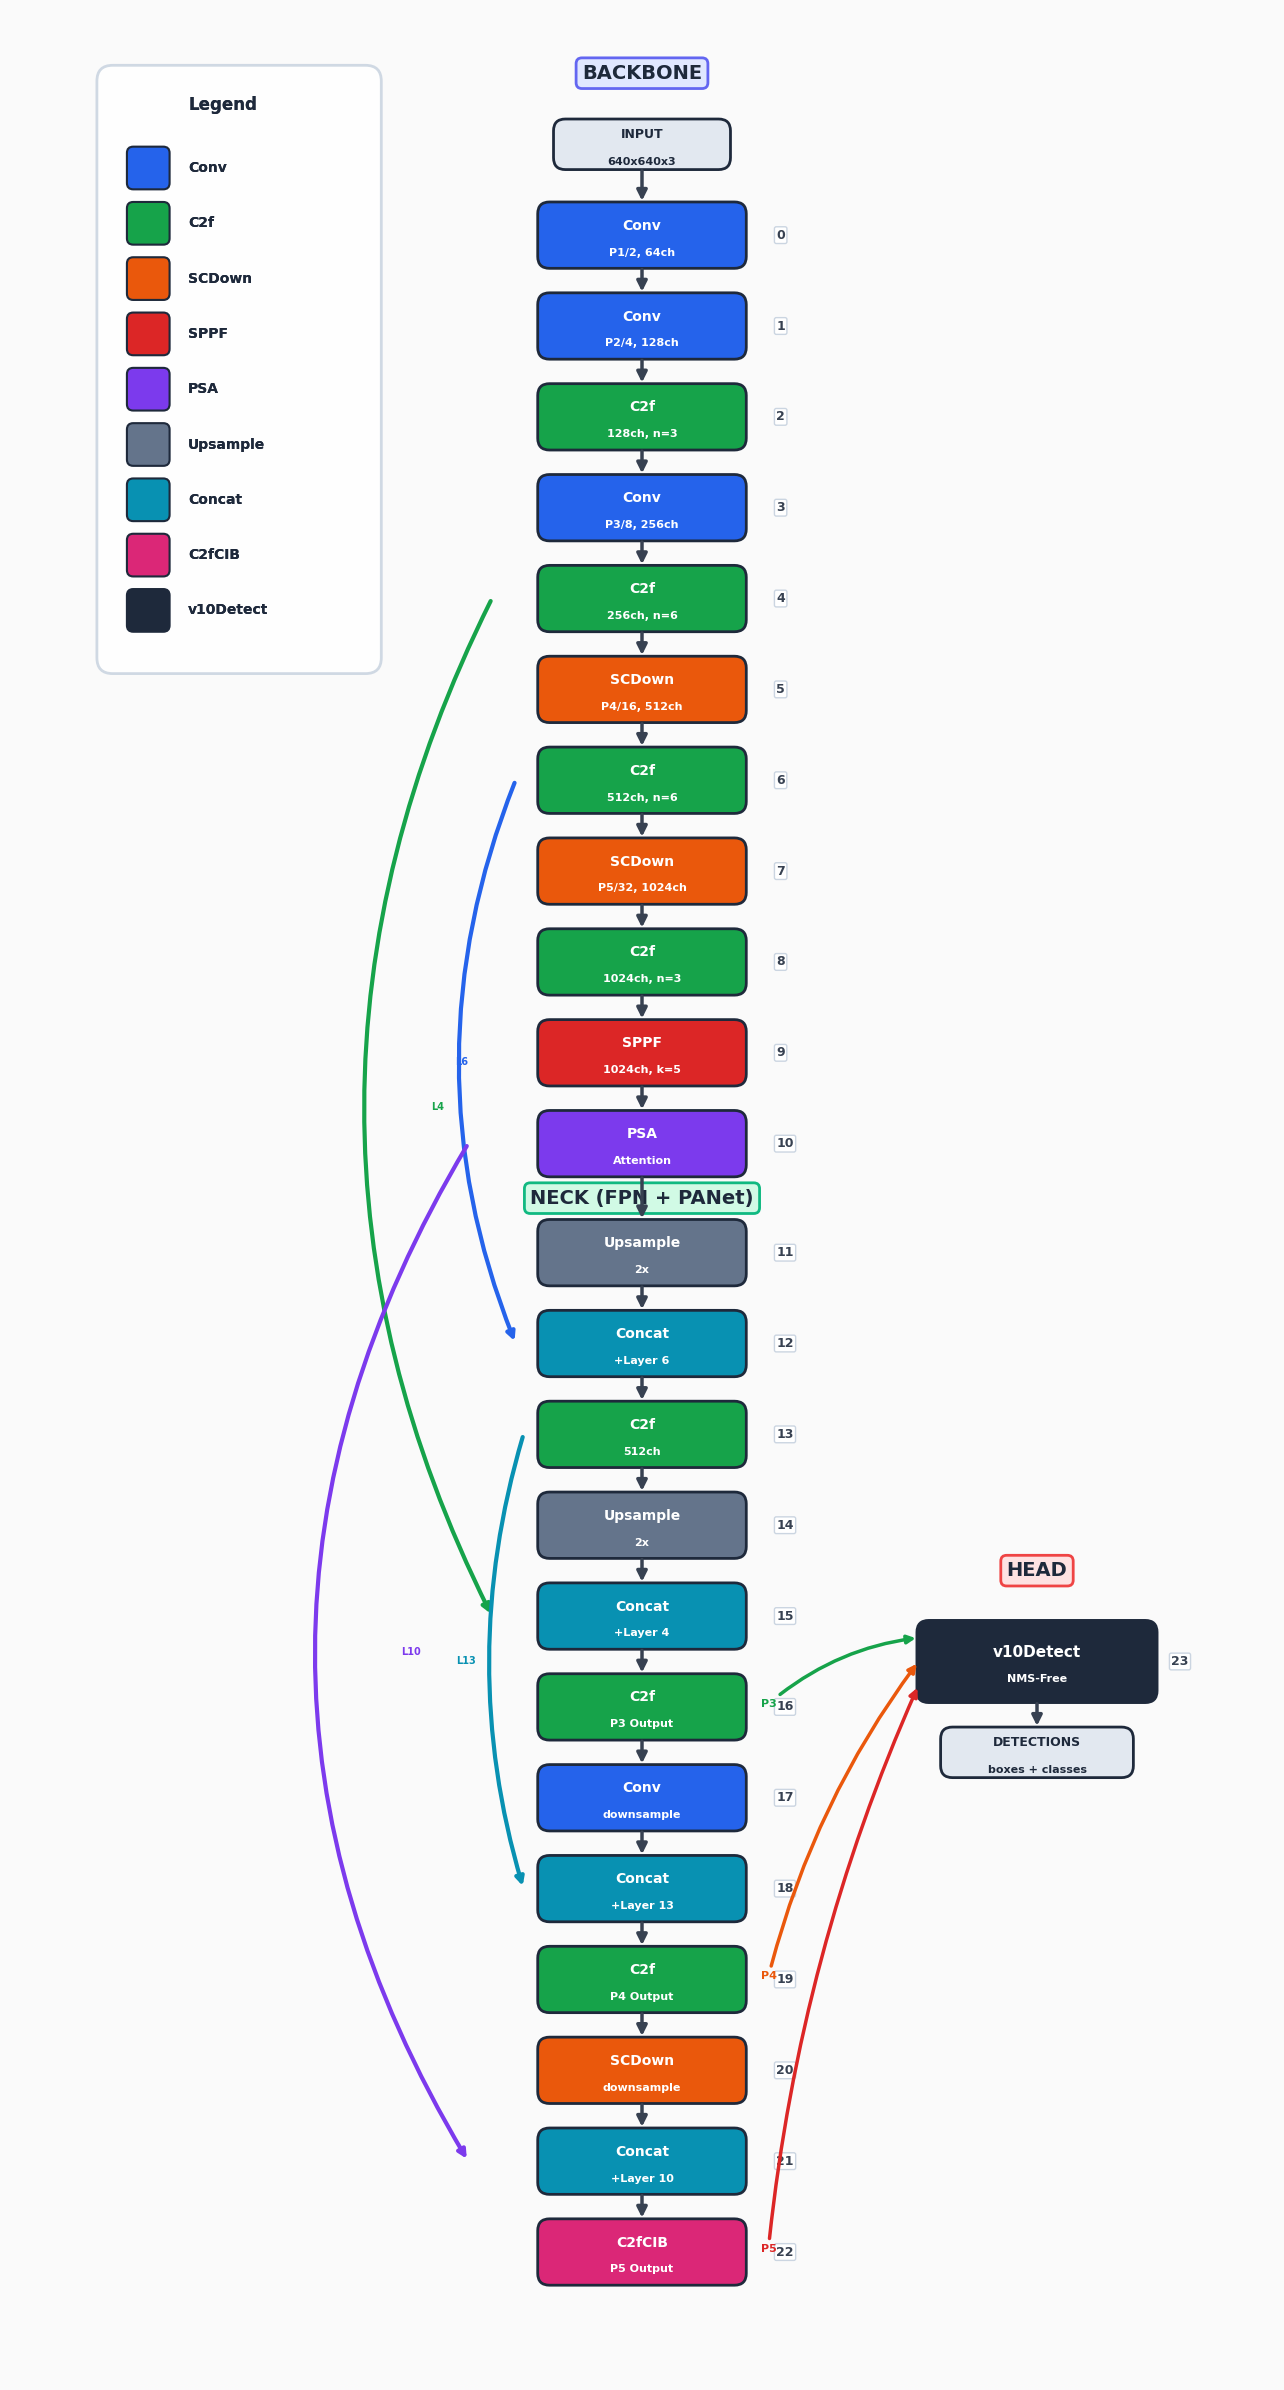

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(1, 1, figsize=(16, 24))
ax.set_xlim(0, 16)
ax.set_ylim(-2, 28)  # Extended to accommodate larger spacing
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Enhanced colors with better contrast
colors = {
    'conv': '#2563EB',      # Bright blue
    'c2f': '#16A34A',       # Vivid green
    'scdown': '#EA580C',    # Bright orange
    'sppf': '#DC2626',      # Vivid red
    'psa': '#7C3AED',       # Purple (attention)
    'upsample': '#64748B',  # Slate gray
    'concat': '#0891B2',    # Cyan
    'c2fcib': '#DB2777',    # Pink
    'detect': '#1E293B',    # Dark slate
    'input': '#E2E8F0',     # Light gray
}

# Text colors for each block type (ensuring contrast)
text_colors = {
    'conv': 'white',
    'c2f': 'white',
    'scdown': 'white',
    'sppf': 'white',
    'psa': 'white',
    'upsample': 'white',
    'concat': 'white',
    'c2fcib': 'white',
    'detect': 'white',
    'input': '#1E293B',  # Dark text on light background
}

def draw_block(ax, x, y, w, h, label, sublabel, ctype, fontsize=10):
    color = colors[ctype]
    txt_color = text_colors[ctype]
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.02,rounding_size=0.15",
                         facecolor=color, edgecolor='#1E293B', linewidth=2)
    ax.add_patch(box)
    ax.text(x, y + 0.12, label, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=txt_color)
    if sublabel:
        ax.text(x, y - 0.22, sublabel, ha='center', va='center', fontsize=8,
                color=txt_color, fontweight='bold')

def draw_flow_arrow(ax, x1, y1, x2, y2):
    """Main flow arrows - thick and visible, from bottom of source to top of dest"""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color='#374151', lw=2.5,
                               mutation_scale=15))

def draw_skip_arrow(ax, x1, y1, x2, y2, color, label=None, rad=0.3):
    """Skip connection arrows - curved and colored"""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=3,
                               connectionstyle=f'arc3,rad={rad}',
                               mutation_scale=12))
    if label:
        mid_y = (y1 + y2) / 2
        ax.text(x1 - 0.6, mid_y, label, ha='right', va='center', fontsize=7,
                color=color, fontweight='bold')

# Layout
cx = 8  # Center x
bw, bh = 2.6, 0.8  # Block width, height
spacing = 1.15  # Increased spacing between blocks (was 1.0)

# === BACKBONE ===
ax.text(cx, 27.2, 'BACKBONE', ha='center', va='center', fontsize=14,
        fontweight='bold', color='#1E293B',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E0E7FF', edgecolor='#6366F1', lw=2))

# Input block height
input_h = 0.6
input_y = 26.3
draw_block(ax, cx, input_y, 2.2, input_h, 'INPUT', '640x640x3', 'input', 9)

# Backbone layers with increased spacing
backbone = [
    (input_y - spacing, 'Conv', 'P1/2, 64ch', 'conv'),
]
for i in range(1, 11):
    backbone.append((backbone[-1][0] - spacing, '', '', ''))

# Redefine with actual labels
backbone = [
    (input_y - spacing * 1, 'Conv', 'P1/2, 64ch', 'conv'),
    (input_y - spacing * 2, 'Conv', 'P2/4, 128ch', 'conv'),
    (input_y - spacing * 3, 'C2f', '128ch, n=3', 'c2f'),
    (input_y - spacing * 4, 'Conv', 'P3/8, 256ch', 'conv'),
    (input_y - spacing * 5, 'C2f', '256ch, n=6', 'c2f'),
    (input_y - spacing * 6, 'SCDown', 'P4/16, 512ch', 'scdown'),
    (input_y - spacing * 7, 'C2f', '512ch, n=6', 'c2f'),
    (input_y - spacing * 8, 'SCDown', 'P5/32, 1024ch', 'scdown'),
    (input_y - spacing * 9, 'C2f', '1024ch, n=3', 'c2f'),
    (input_y - spacing * 10, 'SPPF', '1024ch, k=5', 'sppf'),
    (input_y - spacing * 11, 'PSA', 'Attention', 'psa'),
]

# Draw backbone blocks and arrows
# Arrow from INPUT (bottom) to first backbone block (top)
draw_flow_arrow(ax, cx, input_y - input_h/2, cx, backbone[0][0] + bh/2)
for i, (y, label, sublabel, ctype) in enumerate(backbone):
    draw_block(ax, cx, y, bw, bh, label, sublabel, ctype)
    if i > 0:
        # Arrow from previous block bottom to current block top
        prev_y = backbone[i-1][0]
        draw_flow_arrow(ax, cx, prev_y - bh/2, cx, y + bh/2)

# Layer numbers on right - in boxes for visibility
for i, (y, _, _, _) in enumerate(backbone):
    ax.text(cx + bw/2 + 0.4, y, f'{i}', ha='left', va='center', fontsize=9,
            color='#374151', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='#CBD5E1', lw=1))

# === NECK ===
psa_y = backbone[-1][0]  # PSA y position
neck_label_y = psa_y - spacing * 0.6
ax.text(cx, neck_label_y, 'NECK (FPN + PANet)', ha='center', va='center', fontsize=14,
        fontweight='bold', color='#1E293B',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#D1FAE5', edgecolor='#10B981', lw=2))

neck_start_y = neck_label_y - spacing * 0.6
neck = [
    (neck_start_y - spacing * 0, 'Upsample', '2x', 'upsample'),
    (neck_start_y - spacing * 1, 'Concat', '+Layer 6', 'concat'),
    (neck_start_y - spacing * 2, 'C2f', '512ch', 'c2f'),
    (neck_start_y - spacing * 3, 'Upsample', '2x', 'upsample'),
    (neck_start_y - spacing * 4, 'Concat', '+Layer 4', 'concat'),
    (neck_start_y - spacing * 5, 'C2f', 'P3 Output', 'c2f'),
    (neck_start_y - spacing * 6, 'Conv', 'downsample', 'conv'),
    (neck_start_y - spacing * 7, 'Concat', '+Layer 13', 'concat'),
    (neck_start_y - spacing * 8, 'C2f', 'P4 Output', 'c2f'),
    (neck_start_y - spacing * 9, 'SCDown', 'downsample', 'scdown'),
    (neck_start_y - spacing * 10, 'Concat', '+Layer 10', 'concat'),
    (neck_start_y - spacing * 11, 'C2fCIB', 'P5 Output', 'c2fcib'),
]

# Connect backbone (PSA) to neck (Upsample)
draw_flow_arrow(ax, cx, psa_y - bh/2, cx, neck[0][0] + bh/2)

# Draw neck blocks and arrows
for i, (y, label, sublabel, ctype) in enumerate(neck):
    draw_block(ax, cx, y, bw, bh, label, sublabel, ctype)
    if i > 0:
        prev_y = neck[i-1][0]
        draw_flow_arrow(ax, cx, prev_y - bh/2, cx, y + bh/2)

# Layer numbers
for i, (y, _, _, _) in enumerate(neck):
    ax.text(cx + bw/2 + 0.4, y, f'{11+i}', ha='left', va='center', fontsize=9,
            color='#374151', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='#CBD5E1', lw=1))

# === SKIP CONNECTIONS (on left side) ===
skip_x = cx - bw/2 - 0.3

# Layer 4 (C2f 256ch) -> Layer 15 (Concat +Layer 4) - GREEN
draw_skip_arrow(ax, skip_x - 0.3, backbone[4][0], skip_x - 0.3, neck[4][0], '#16A34A', 'L4', rad=0.25)

# Layer 6 (C2f 512ch) -> Layer 12 (Concat +Layer 6) - BLUE
draw_skip_arrow(ax, skip_x, backbone[6][0], skip_x, neck[1][0], '#2563EB', 'L6', rad=0.2)

# Layer 10 (PSA) -> Layer 21 (Concat +Layer 10) - PURPLE
draw_skip_arrow(ax, skip_x - 0.6, backbone[10][0], skip_x - 0.6, neck[10][0], '#7C3AED', 'L10', rad=0.3)

# Layer 13 (C2f 512ch in neck) -> Layer 18 (Concat +Layer 13) - CYAN
draw_skip_arrow(ax, skip_x + 0.1, neck[2][0], skip_x + 0.1, neck[7][0], '#0891B2', 'L13', rad=0.15)

# === HEAD ===
head_x = 13
head_label_y = neck[5][0] + spacing * 1.5
ax.text(head_x, head_label_y, 'HEAD', ha='center', va='center', fontsize=14,
        fontweight='bold', color='#1E293B',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEE2E2', edgecolor='#EF4444', lw=2))

detect_h = 1.0
detect_y = head_label_y - spacing
draw_block(ax, head_x, detect_y, 3.0, detect_h, 'v10Detect', 'NMS-Free', 'detect', 11)
ax.text(head_x + 1.7, detect_y, '23', ha='left', va='center', fontsize=9,
        color='#374151', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='#CBD5E1', lw=1))

# Output arrows from P3, P4, P5 to Detect - thick colored arrows
# P3 (Layer 16) -> Detect
ax.annotate('P3', xy=(head_x - 1.5, detect_y + 0.3), xytext=(cx + bw/2 + 0.2, neck[5][0]),
            arrowprops=dict(arrowstyle='-|>', color='#16A34A', lw=2.5,
                           connectionstyle='arc3,rad=-0.15', mutation_scale=12),
            fontsize=8, fontweight='bold', color='#16A34A')

# P4 (Layer 19) -> Detect
ax.annotate('P4', xy=(head_x - 1.5, detect_y), xytext=(cx + bw/2 + 0.2, neck[8][0]),
            arrowprops=dict(arrowstyle='-|>', color='#EA580C', lw=2.5,
                           connectionstyle='arc3,rad=-0.1', mutation_scale=12),
            fontsize=8, fontweight='bold', color='#EA580C')

# P5 (Layer 22) -> Detect
ax.annotate('P5', xy=(head_x - 1.5, detect_y - 0.3), xytext=(cx + bw/2 + 0.2, neck[11][0]),
            arrowprops=dict(arrowstyle='-|>', color='#DC2626', lw=2.5,
                           connectionstyle='arc3,rad=-0.08', mutation_scale=12),
            fontsize=8, fontweight='bold', color='#DC2626')

# Output
output_h = 0.6
output_y = detect_y - spacing
draw_block(ax, head_x, output_y, 2.4, output_h, 'DETECTIONS', 'boxes + classes', 'input', 9)
draw_flow_arrow(ax, head_x, detect_y - detect_h/2, head_x, output_y + output_h/2)

# === LEGEND ===
legend_x = 1.5
legend_y = 26
ax.text(legend_x + 1.2, legend_y + 0.8, 'Legend', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#1E293B')

legend_items = [
    ('Conv', 'conv'),
    ('C2f', 'c2f'),
    ('SCDown', 'scdown'),
    ('SPPF', 'sppf'),
    ('PSA', 'psa'),
    ('Upsample', 'upsample'),
    ('Concat', 'concat'),
    ('C2fCIB', 'c2fcib'),
    ('v10Detect', 'detect'),
]

for i, (label, ctype) in enumerate(legend_items):
    y = legend_y - i * 0.7
    box = FancyBboxPatch((legend_x, y - 0.25), 0.5, 0.5,
                         boxstyle="round,pad=0.02,rounding_size=0.08",
                         facecolor=colors[ctype], edgecolor='#1E293B', linewidth=1.5)
    ax.add_patch(box)
    ax.text(legend_x + 0.75, y, label, ha='left', va='center', fontsize=10,
            color='#1E293B', fontweight='bold')

# Legend box
legend_box = FancyBboxPatch((legend_x - 0.3, legend_y - 6.3), 3.4, 7.5,
                            boxstyle="round,pad=0.1,rounding_size=0.2",
                            facecolor='white', edgecolor='#CBD5E1', linewidth=2, alpha=0.9)
ax.add_patch(legend_box)
ax.set_zorder(1)

# Redraw legend on top
ax.text(legend_x + 1.2, legend_y + 0.8, 'Legend', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#1E293B')
for i, (label, ctype) in enumerate(legend_items):
    y = legend_y - i * 0.7
    box = FancyBboxPatch((legend_x, y - 0.25), 0.5, 0.5,
                         boxstyle="round,pad=0.02,rounding_size=0.08",
                         facecolor=colors[ctype], edgecolor='#1E293B', linewidth=1.5)
    ax.add_patch(box)
    ax.text(legend_x + 0.75, y, label, ha='left', va='center', fontsize=10,
            color='#1E293B', fontweight='bold')

plt.tight_layout()
plt.savefig('yolov10_architecture.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

---

## Key YOLOv10 Innovations

| Innovation | Description |
|:-----------|:------------|
| **NMS-Free Detection** | Dual label assignment with one2one head for inference |
| **PSA** | Position-Sensitive Attention for enhanced P5 features |
| **SCDown** | Efficient spatial-channel decoupled downsampling |
| **C2fCIB** | Compact Inverted Blocks for improved efficiency |
| **Lightweight Cls Head** | Reduced computational cost in classification |
| **End-to-End** | No post-processing required during inference |